Training on device: mps

--- Problem 1: Sine Wave ---
Iter 1/5 | u(a)=0.31490, u(b)=0.52559
Iter 2/5 | u(a)=0.66698, u(b)=0.76085
Iter 3/5 | u(a)=0.82415, u(b)=0.86633
Iter 4/5 | u(a)=0.89452, u(b)=0.91335
Iter 5/5 | u(a)=0.92591, u(b)=0.93428
Time: 32.83s
  Max Error: 0.018381 | Rel L2: 0.014649

--- Problem 2: Polynomial ---
Iter 1/5 | u(a)=0.08016, u(b)=0.13390
Iter 2/5 | u(a)=0.16927, u(b)=0.19300
Iter 3/5 | u(a)=0.20866, u(b)=0.21912
Iter 4/5 | u(a)=0.22608, u(b)=0.23072
Iter 5/5 | u(a)=0.23381, u(b)=0.23587
Time: 33.90s
  Max Error: 0.004518 | Rel L2: 0.013934

--- Problem 3: High-Freq Sine ---
Iter 1/5 | u(a)=0.87860, u(b)=-0.28599
Iter 2/5 | u(a)=0.68507, u(b)=-0.41894
Iter 3/5 | u(a)=0.59738, u(b)=-0.47431
Iter 4/5 | u(a)=0.55302, u(b)=-0.50313
Iter 5/5 | u(a)=0.54269, u(b)=-0.51786
Time: 33.91s
  Max Error: 0.097499 | Rel L2: 0.089220

--- Problem 4: Exponential ---
Iter 1/5 | u(a)=0.27682, u(b)=1.01126
Iter 2/5 | u(a)=0.95124, u(b)=1.46176
Iter 3/5 | u(a)=1.25158, u(b)=1.661

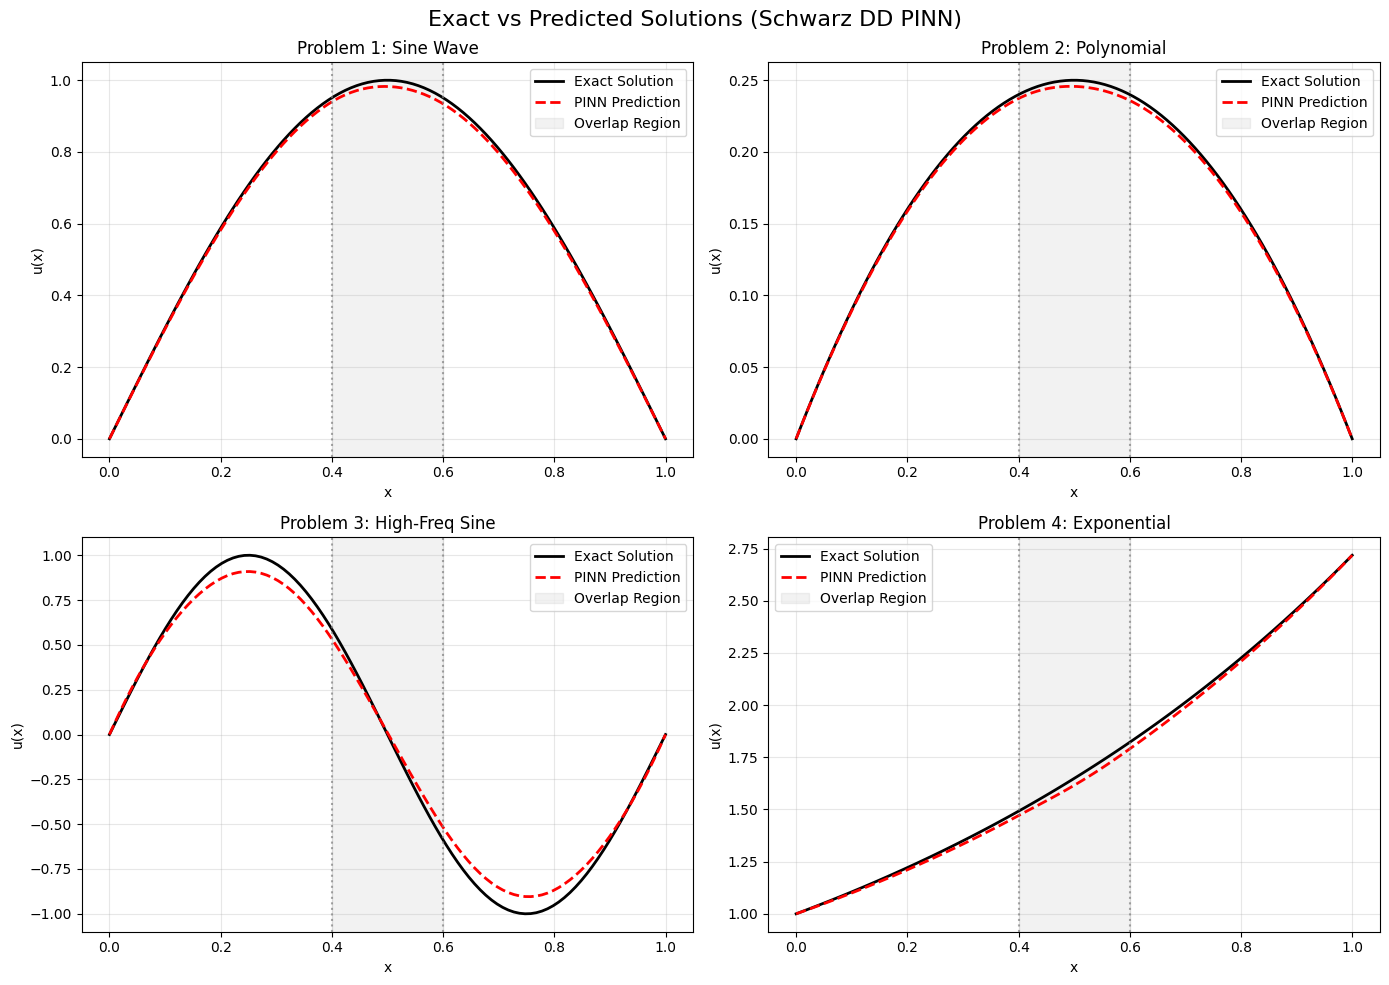

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)

# 1. HARDWARE PARITY
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# 2. STANDARD CAPACITY (Two networks of width 32)
class HardPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x, x_left, x_right, ua, ub):
        lift = ua + (x - x_left) / (x_right - x_left) * (ub - ua)
        D    = (x - x_left) * (x - x_right)
        return lift + D * self.net(x)

def create_model():
    return HardPINN().to(device)

def d2u_dx2_hard(model, x, xl, xr, ua, ub):
    x = x.clone().detach().requires_grad_(True)
    u = model(x, xl, xr, ua, ub)
    du  = torch.autograd.grad(u,  x, grad_outputs=torch.ones_like(u),  create_graph=True)[0]
    d2u = torch.autograd.grad(du, x, grad_outputs=torch.ones_like(du), create_graph=True)[0]
    return d2u

def train_subdomain(net, optimizer, f, x_left, u_left, x_right, u_right, x_lo, x_hi, epochs=800, n_collocation=500):
    t0 = time.perf_counter()
    ua = torch.tensor([[u_left]],  dtype=torch.float32, device=device)
    ub = torch.tensor([[u_right]], dtype=torch.float32, device=device)
    xl = torch.tensor([[x_left]],  dtype=torch.float32, device=device)
    xr = torch.tensor([[x_right]], dtype=torch.float32, device=device)

    for epoch in range(epochs):
        x_int = (x_hi - x_lo) * torch.rand(n_collocation, 1, device=device) + x_lo
        x_int.requires_grad_(True)
        d2u   = d2u_dx2_hard(net, x_int, xl, xr, ua, ub)
        loss  = torch.mean((-d2u - f(x_int)) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return time.perf_counter() - t0

# 3. STRICT COMPUTATIONAL BUDGET (5 iters * 800 epochs = 4000 per net = 8000 total updates)
def schwarz_alternating(f, bc_left, bc_right, overlap_a=0.4, overlap_b=0.6, schwarz_iters=5, epochs_per_iter=800, lr=1e-3):
    x0, u0 = bc_left
    x1, u1 = bc_right

    net1, net2 = create_model(), create_model()
    optimizer1 = torch.optim.Adam(net1.parameters(), lr=lr)
    optimizer2 = torch.optim.Adam(net2.parameters(), lr=lr)

    def get_interface_val(model, x_val, x_l, x_r, ua, ub):
        xt  = torch.tensor([[x_val]], dtype=torch.float32, device=device)
        xlt = torch.tensor([[x_l]],  dtype=torch.float32, device=device)
        xrt = torch.tensor([[x_r]],  dtype=torch.float32, device=device)
        uat = torch.tensor([[ua]],   dtype=torch.float32, device=device)
        ubt = torch.tensor([[ub]],   dtype=torch.float32, device=device)
        with torch.no_grad():
            return model(xt, xlt, xrt, uat, ubt).item()

    u_at_a, u_at_b = 0.0, 0.0
    total_elapsed  = 0.0

    for it in range(schwarz_iters):
        # Train Domain 1
        t1 = train_subdomain(net1, optimizer1, f, x0, u0, overlap_b, u_at_b, x0, overlap_b, epochs_per_iter)
        total_elapsed += t1
        u_at_a = get_interface_val(net1, overlap_a, x0, overlap_b, u0, u_at_b)
        
        # Train Domain 2
        t2 = train_subdomain(net2, optimizer2, f, overlap_a, u_at_a, x1, u1, overlap_a, x1, epochs_per_iter)
        total_elapsed += t2
        u_at_b = get_interface_val(net2, overlap_b, overlap_a, x1, u_at_a, u1)

        print(f"Iter {it+1}/{schwarz_iters} | u(a)={u_at_a:.5f}, u(b)={u_at_b:.5f}")

    return net1.to('cpu'), net2.to('cpu'), total_elapsed, u_at_a, u_at_b

def evaluate_schwarz(net1, net2, exact_fn, overlap_a, overlap_b, u_left, u_right, u_at_a, u_at_b):
    x = torch.linspace(0, 1, 100).unsqueeze(1)
    
    # Evaluate net 1 and 2
    ua_1 = torch.full((100, 1), u_left); ub_1 = torch.full((100, 1), u_at_b)
    ua_2 = torch.full((100, 1), u_at_a); ub_2 = torch.full((100, 1), u_right)
    xl1, xr1 = torch.zeros(100, 1), torch.full((100, 1), overlap_b)
    xl2, xr2 = torch.full((100, 1), overlap_a), torch.ones(100, 1)

    with torch.no_grad():
        p1 = net1(x, xl1, xr1, ua_1, ub_1).numpy().squeeze()
        p2 = net2(x, xl2, xr2, ua_2, ub_2).numpy().squeeze()

    x_np = x.numpy().squeeze()
    t    = np.clip((x_np - overlap_a) / (overlap_b - overlap_a), 0, 1)
    w2   = 3*t**2 - 2*t**3
    u_pred = np.where(x_np <= overlap_a, p1, np.where(x_np >= overlap_b, p2, (1-w2)*p1 + w2*p2))
    u_exact = exact_fn(x).numpy().squeeze()
    error = np.abs(u_pred - u_exact)
    
    rel_l2 = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    print(f"  Max Error: {np.max(error):.6f} | Rel L2: {rel_l2:.6f}")
    
    # MODIFICATION 1: Return the plot data alongside the metrics
    return {'max_err': np.max(error), 'mean_err': np.mean(error), 'rel_l2': rel_l2}, x_np, u_pred, u_exact

# --- RUN EXPERIMENTS ---
timing_records = []
plot_data = [] # MODIFICATION 2: Create a list to store plot data

problems = [
    ("Problem 1: Sine Wave", lambda x: (torch.pi**2) * torch.sin(torch.pi * x), lambda x: torch.sin(torch.pi * x), 0.0, 0.0),
    ("Problem 2: Polynomial", lambda x: 2.0 * torch.ones_like(x), lambda x: x * (1 - x), 0.0, 0.0),
    ("Problem 3: High-Freq Sine", lambda x: (4 * torch.pi**2) * torch.sin(2 * torch.pi * x), lambda x: torch.sin(2 * torch.pi * x), 0.0, 0.0),
    ("Problem 4: Exponential", lambda x: -torch.exp(x), lambda x: torch.exp(x), 1.0, float(np.exp(1.0)))
]

for name, f, exact, ul, ur in problems:
    print(f"\n--- {name} ---")
    n1, n2, elapsed, ua, ub = schwarz_alternating(f, (0.0, ul), (1.0, ur))
    print(f"Time: {elapsed:.2f}s")
    
    # MODIFICATION 3: Unpack the plot data
    metrics, x_val, u_p, u_e = evaluate_schwarz(n1, n2, exact, 0.4, 0.6, ul, ur, ua, ub)
    
    timing_records.append({'problem': name, 'train_time_s': elapsed, **metrics})
    plot_data.append((name, x_val, u_p, u_e)) # Save for plotting later

print("\nSCHWARZ DD PINN SUMMARY:")
for r in timing_records:
    print(f"{r['problem']:<25} | Time: {r['train_time_s']:>6.2f}s | Rel L2: {r['rel_l2']:.6f}")

# MODIFICATION 4: Generate the 2x2 comparison grid at the very end
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exact vs Predicted Solutions (Schwarz DD PINN)", fontsize=16)

for ax, (name, x_val, u_p, u_e) in zip(axes.flatten(), plot_data):
    ax.plot(x_val, u_e, 'k-', linewidth=2, label="Exact Solution")
    ax.plot(x_val, u_p, 'r--', linewidth=2, label="PINN Prediction")
    
    # Mark the overlapping subdomain region boundaries
    ax.axvline(x=0.4, color='gray', linestyle=':', alpha=0.7)
    ax.axvline(x=0.6, color='gray', linestyle=':', alpha=0.7)
    ax.axvspan(0.4, 0.6, color='gray', alpha=0.1, label="Overlap Region")

    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()